# Descriptive Analysis
**Purpose:** Summarize and visualize the main characteristics of the data to understand distributions and key patterns.

**Tasks:**
1. Summary statistics for numerical features (mean, std, min, max, 25th, 50th, 75th percentiles).
2. Histograms, boxplots, and density plots to inspect the distribution of individual features.
3. Count plots for categorical variables (frequencies of each category).
4. Correlation matrix (using heatmap) to understand relationships between numerical variables.

In [1]:
# importing libraries
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reading data
df = pd.read_csv(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\data\raw\fraud test.csv")
df.shape

(555719, 23)

In [3]:
data = df[df.columns[1:]].copy()
data.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,21/06/2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,19/03/1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,21/06/2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",17/01/1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0


In [4]:
file_path = r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\metadata\Credit_cols_classified.json"
with open(file_path, 'r') as file:
    col_class = json.load(file)
print(col_class)

{'target_col': 'is_fraud', 'uniq_cols': ['cc_num', 'trans_num'], 'num_cols': ['amt', 'city_pop'], 'cat_cols': ['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job'], 'loc_cols': ['long', 'lat', 'merch_lat', 'merch_long', 'zip'], 'time_cols': ['trans_date_trans_time', 'dob', 'unix_time']}


## Univariate Analysis

In [5]:
data[col_class['num_cols']].head()

,amt,city_pop
0,2.86,333497
1,29.84,302
2,41.28,34496
3,60.05,54767
4,3.19,1126


We should divide and seperate **numerical** columns and **location** related columns\
loc_cols = long, lat, merch_lat, merch_long

In [6]:
loc_cols = ["long", "lat", "merch_lat", "merch_long"]
num_cols = [col for col in col_class.get("num_cols") if col not in loc_cols]

In [7]:
len(num_cols)

2

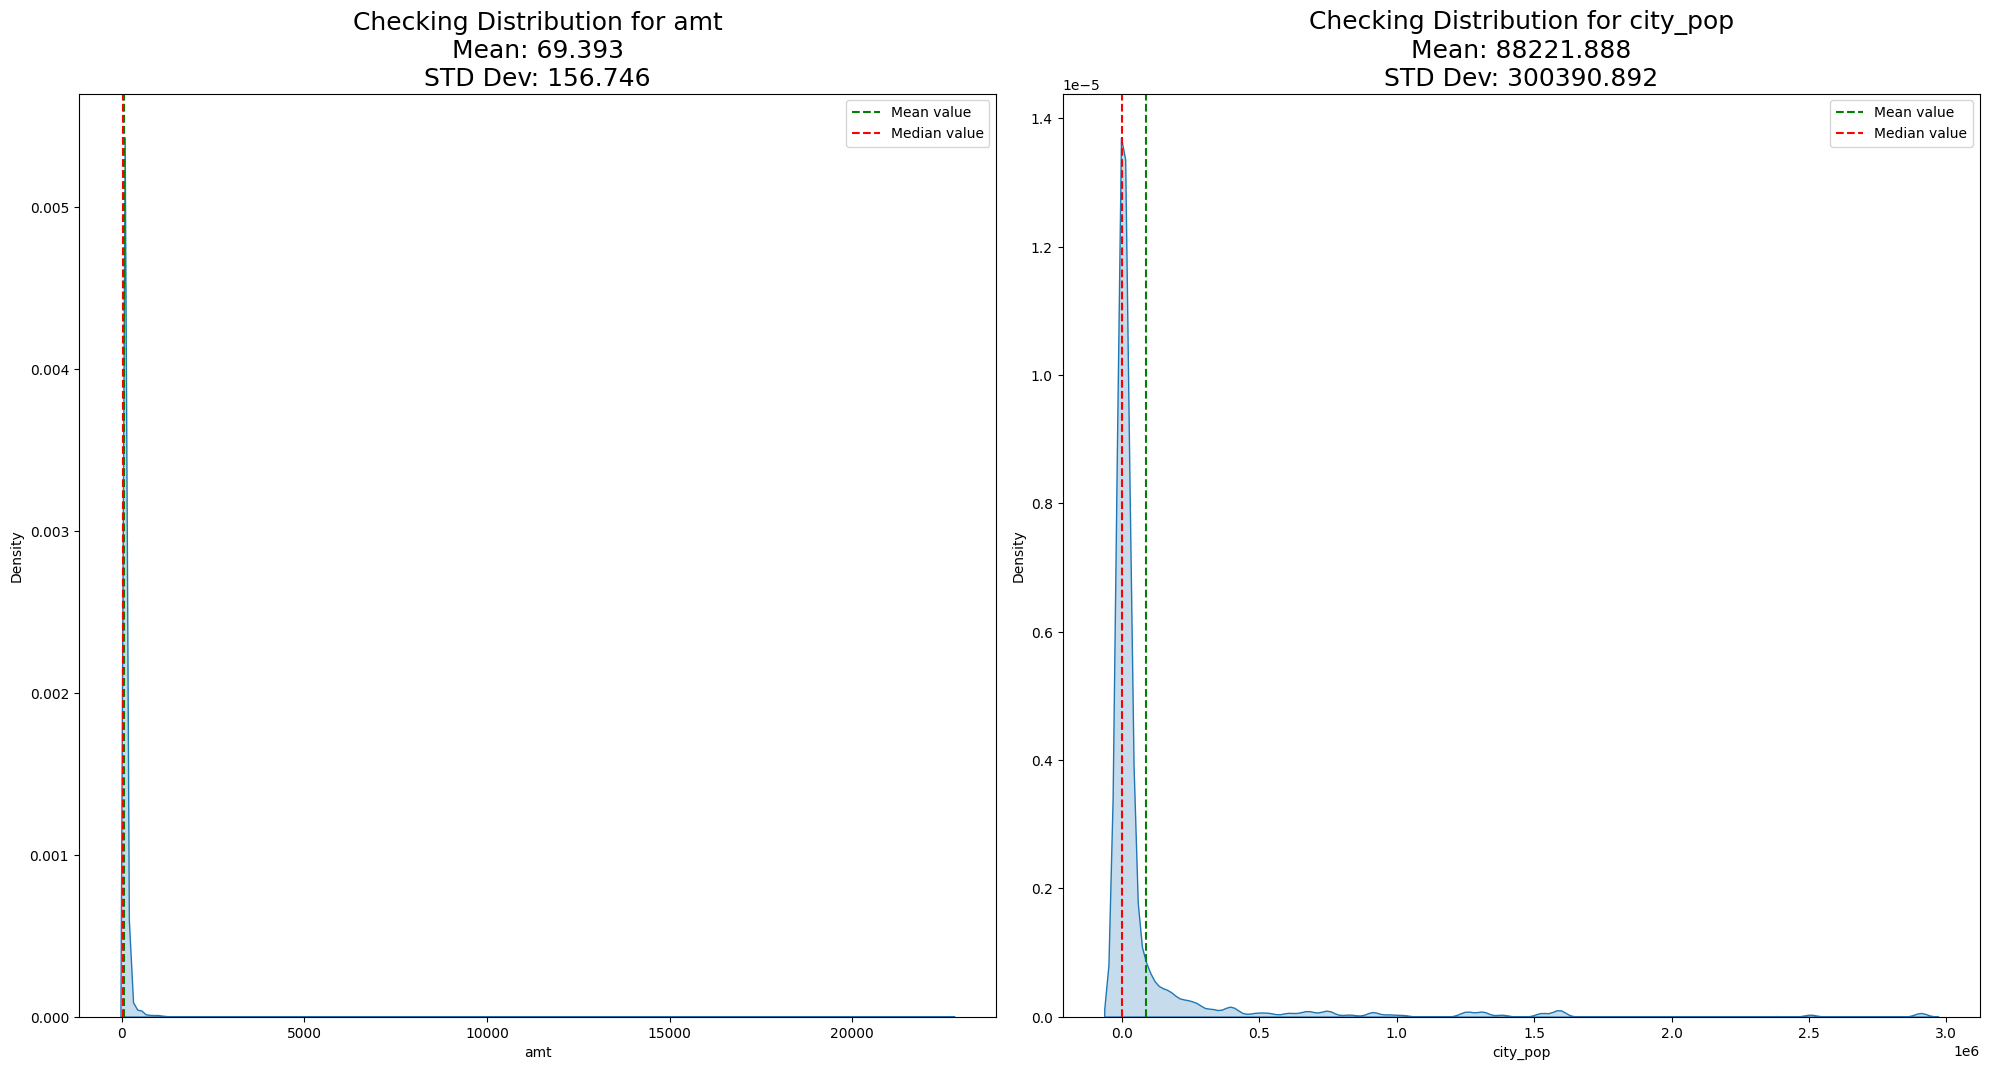

In [8]:
# now let's make Kde plot for checking the distribution of numerical columns
rows, cols, t = 3,2,1
plt.figure(figsize=(20,30))
for i in range(len(num_cols)):
    plt.subplot(rows,cols,t+i)
    mean_val = data[num_cols[i]].mean()
    med_val = data[num_cols[i]].median()
    std_dev = data[num_cols[i]].std()
    plt.title(f"Checking Distribution for {num_cols[i]}\nMean: {round(mean_val,3)}\nSTD Dev: {round(std_dev,3)}",
              fontsize = 18)
    sns.kdeplot(data=data, x=num_cols[i], fill=True)
    plt.axvline(mean_val, linestyle = "--", color = "green",label = "Mean value")
    plt.axvline(med_val, linestyle = "--", color = "red", label = "Median value")
    plt.legend()
plt.tight_layout()
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\univariate\Fraud_num_cols_kde_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

*Inference:* From here we can inference about the columns: 
1. amt (transaction amount): Is `right skewed` which show us that the there are ocassional large transaction for some cc_num which could mean 2 things either we have customer with large transaction history or for the customer who usually do low transaction might be facing some fraud. 
2. is_fraud (target column): There is a visible `data imbalance` present.
3. city_pop (city population): this indicate that, there are cities with much greater population and this might be `leading to large number of transcations hapening in a day`.

In [9]:
# Get the value counts for the is_fraud column
data["is_fraud"].value_counts(normalize=True)*100

is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64

**This type of result is common for fraud detection data. It also show us that there is critical need for using techniques like oversampling and threshold setting**

C:\Users\HP\AppData\Local\Temp\ipykernel_5292\3398934598.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  sns.histplot(pd.to_datetime(data[col_class["time_cols"][0]]))


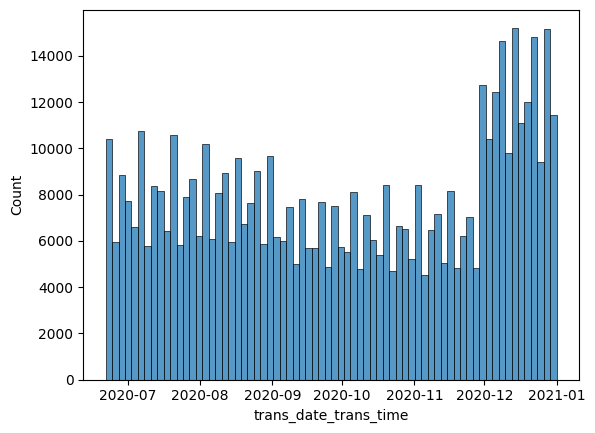

In [10]:
sns.histplot(pd.to_datetime(data[col_class["time_cols"][0]]))
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\univariate\Fraud_trans_date_distribution.png", dpi=300, bbox_inches='tight')

This plot show us that transaction count decreases in Q2 and Q3 but in Q4 transaction count increases. so there might be a chance that if a anonymus high value transaction is occoured then it may be a fraud.

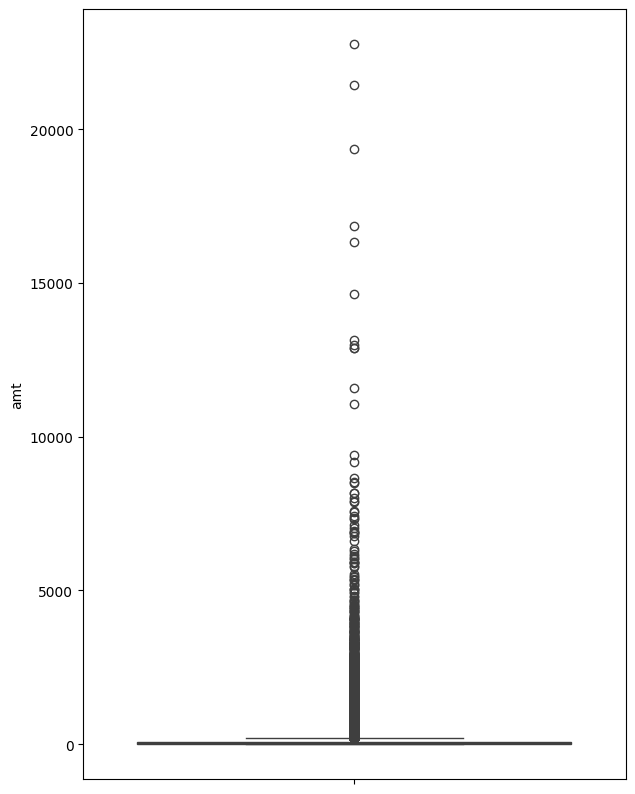

In [11]:
plt.figure(figsize=(7,10))
sns.boxplot(data=data,y="amt")
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\univariate\Fraud_amt_box_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Bivariate Analysis

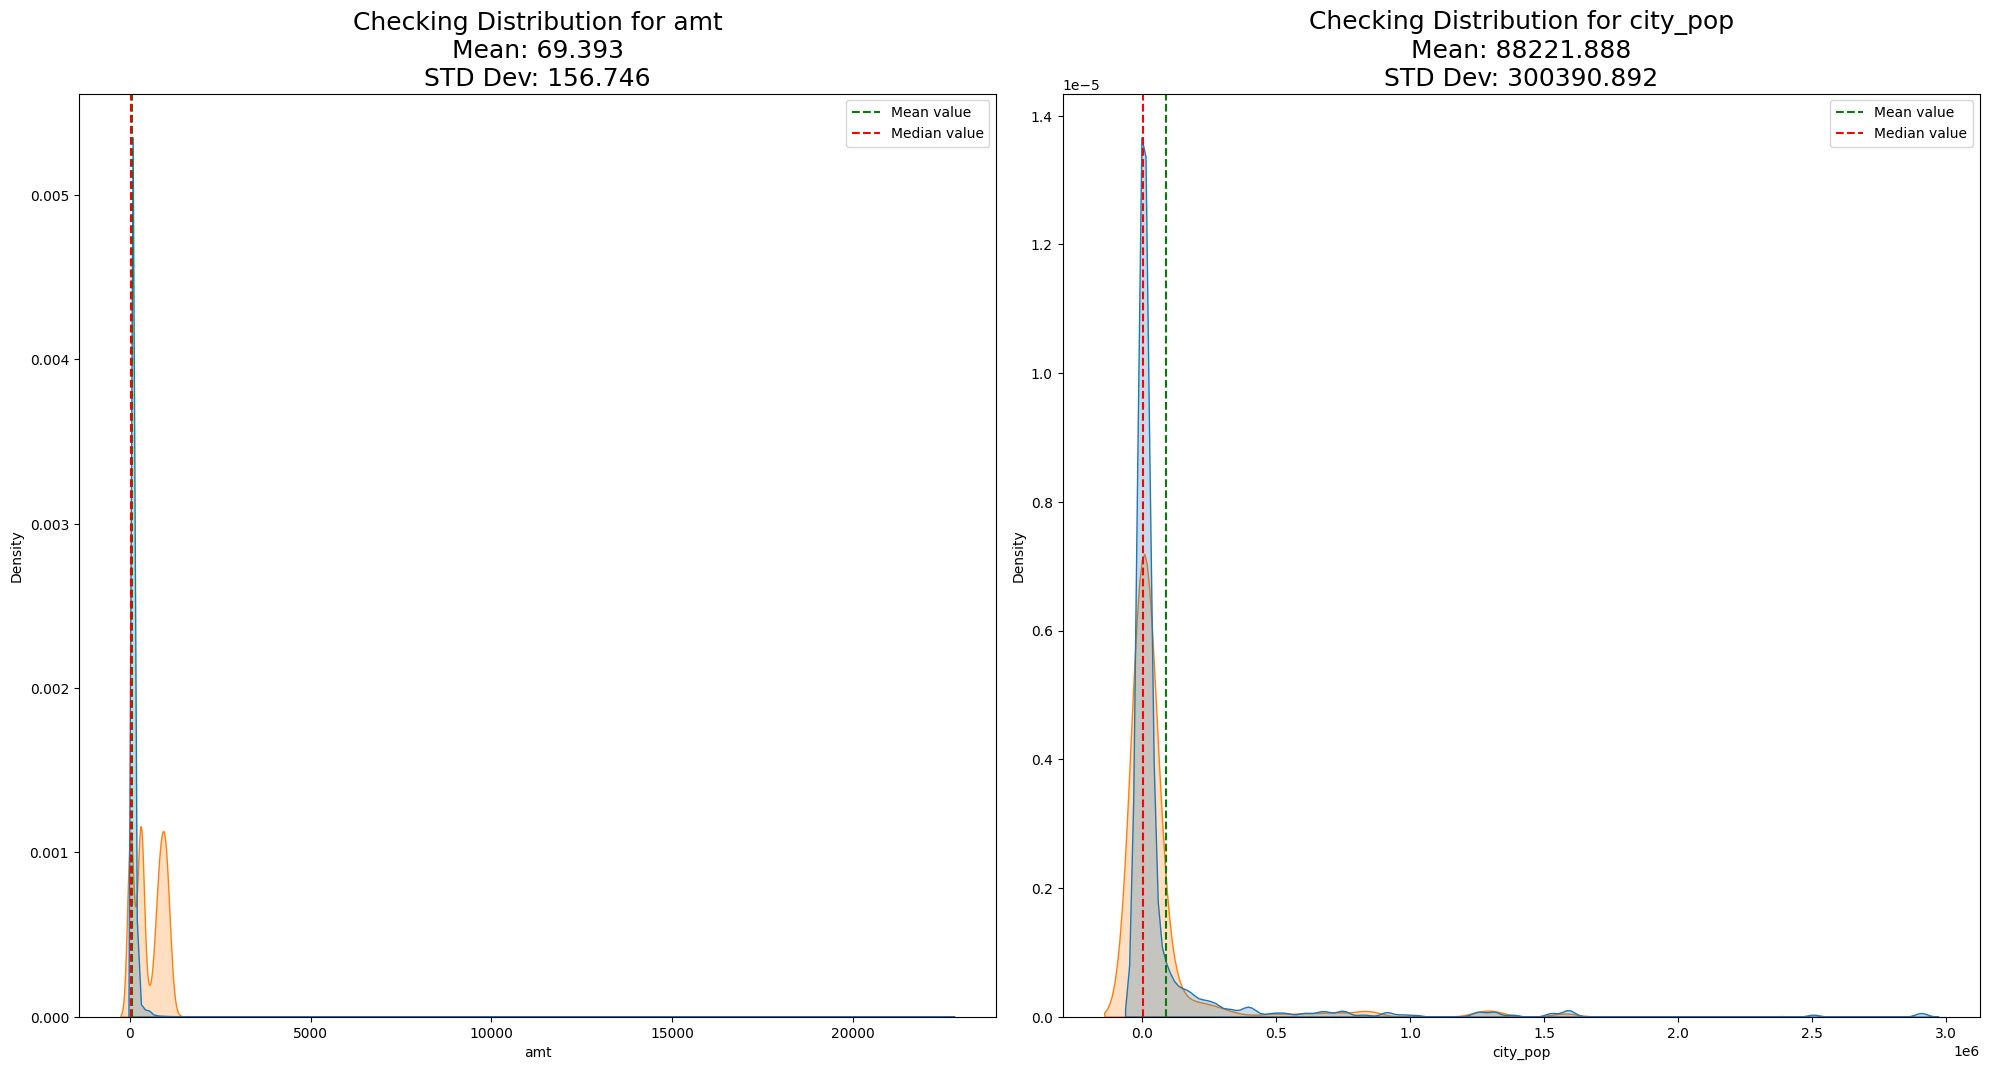

In [12]:
# now let's make Kde plot for checking the distribution of numerical columns
rows, cols, t = 3,2,1
plt.figure(figsize=(20,30))
for i in range(len(num_cols)):
    plt.subplot(rows,cols,t+i)
    mean_val = data[num_cols[i]].mean()
    med_val = data[num_cols[i]].median()
    std_dev = data[num_cols[i]].std()
    plt.title(f"Checking Distribution for {num_cols[i]}\nMean: {round(mean_val,3)}\nSTD Dev: {round(std_dev,3)}",
              fontsize = 18)
    sns.kdeplot(data=data, x=num_cols[i],hue="is_fraud", fill=True,common_norm=False)
    plt.axvline(mean_val, linestyle = "--", color = "green",label = "Mean value")
    plt.axvline(med_val, linestyle = "--", color = "red", label = "Median value")
    plt.legend()
plt.tight_layout()
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\bivariate\Fraud_nums_distribution_vs_cat_cols.png", dpi=300, bbox_inches='tight')
plt.show()

The distribution for minority class is not visible because of big data imbalance, but we can say that the majourity class covers minorty data too. 

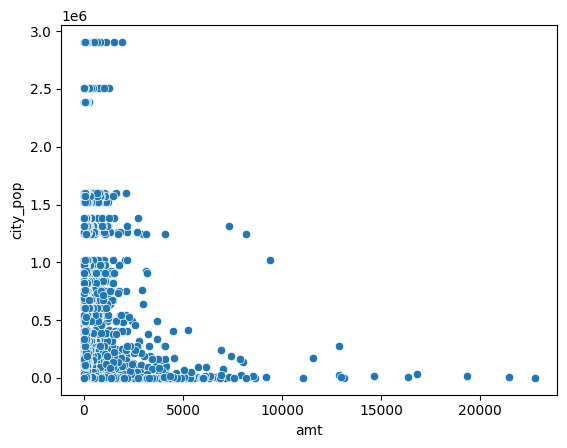

In [13]:
sns.scatterplot(data=data,x="amt",y="city_pop")
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\bivariate\Fraud_amt_vs_city_pop.png", dpi=300, bbox_inches='tight')
plt.show()

This plot shows that there is no corelation between amt and city_pop column.

## Multivariate and Categorical Data Analysis

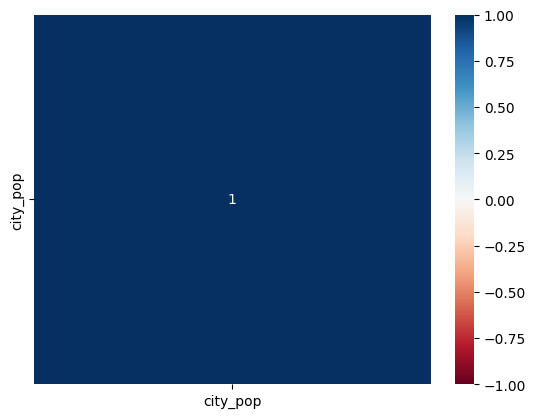

In [14]:
sns.heatmap(data=data[num_cols[1:]].corr(),cmap="RdBu", vmin=-1, annot=True)
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\Fraud_cols_heatmap.png", dpi=300, bbox_inches='tight')


Here we can see that there is no correlation between the columns and there is only low correlation between amount (`amt`) and `is_fraud`.

In [15]:
loc_col = ["long", "lat", "merch_lat", "merch_long","zip"]

In [16]:
# Updating the column division for further improvment
uniq_cols = ['cc_num','trans_num']
target_col = 'is_fraud'
loc_cols = ["long", "lat", "merch_lat", "merch_long","zip"]
time_cols = ['trans_date_trans_time', 'dob', 'unix_time']
num_cols = [i for i in num_cols if i!=target_col and i not in uniq_cols and i not in loc_cols and i not in time_cols]
cat_cols = ['merchant', 'category', 'first', 'last', 'gender', 'street',
  'city', 'state', 'job']

In [17]:
col_div = {"target_col":'is_fraud',
           "uniq_cols":['cc_num','trans_num'],
           "num_cols":num_cols,
           "cat_cols":cat_cols,
           "loc_cols":loc_cols,
           "time_cols":time_cols}
col_div

{'target_col': 'is_fraud',
 'uniq_cols': ['cc_num', 'trans_num'],
 'num_cols': ['amt', 'city_pop'],
 'cat_cols': ['merchant',
  'category',
  'first',
  'last',
  'gender',
  'street',
  'city',
  'state',
  'job'],
 'loc_cols': ['long', 'lat', 'merch_lat', 'merch_long', 'zip'],
 'time_cols': ['trans_date_trans_time', 'dob', 'unix_time']}

In [18]:
with open(file_path, 'w') as file:
    json.dump(col_div,file,indent=4)

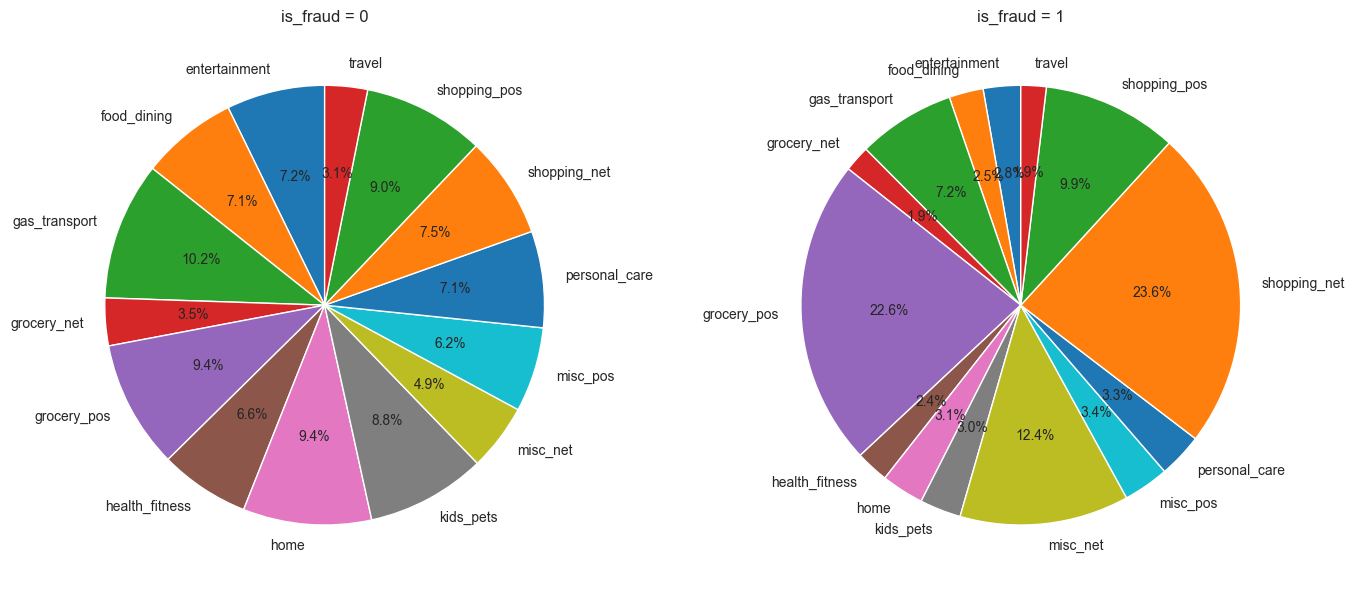

In [19]:
sns.set_style("whitegrid")

fraud_category_df = data.groupby(["is_fraud", "category"]).size().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for i, col in enumerate(fraud_category_df.index):
    axes[i].pie(
        fraud_category_df.loc[col],
        labels=fraud_category_df.columns,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(f"is_fraud = {col}")

plt.tight_layout()
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\bivariate\is_fraud_category_dist.png", dpi=300, bbox_inches='tight')
plt.show()

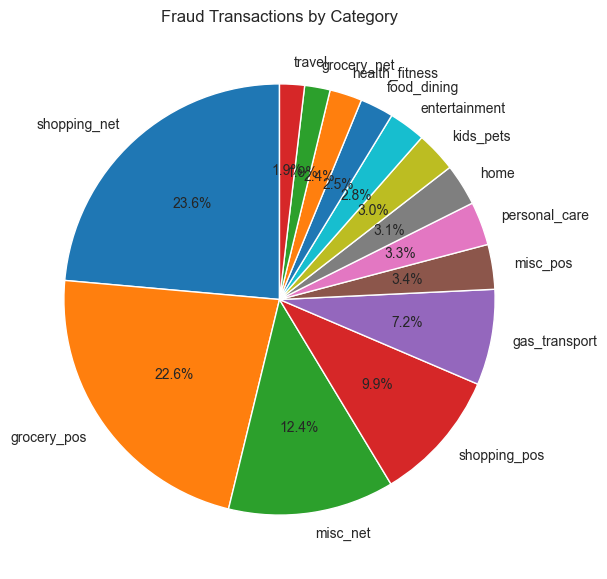

In [20]:
fraud_only = data[data["is_fraud"] == 1]["category"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    fraud_only,
    labels=fraud_only.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Fraud Transactions by Category")
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\bivariate\Fraud_category_dist.png", dpi=300, bbox_inches='tight')
plt.show()

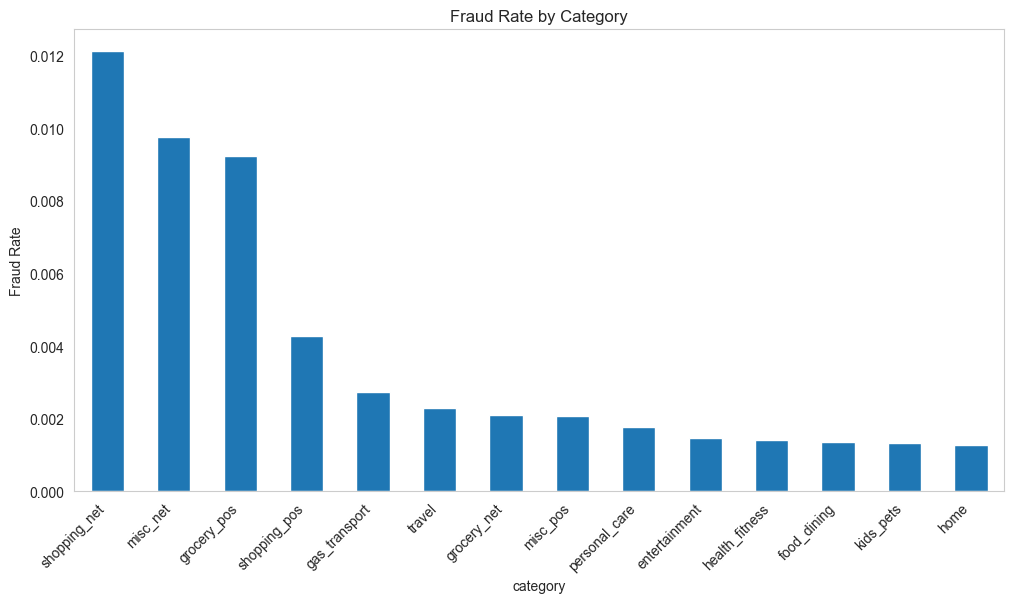

In [21]:
fraud_rate = data.groupby("category")["is_fraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
fraud_rate.plot(kind="bar")

plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Category")
plt.xticks(rotation=45, ha='right')
plt.grid(visible=False)
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\bivariate\Fraud_rate_category_dist.png", dpi=300, bbox_inches='tight')
plt.show()

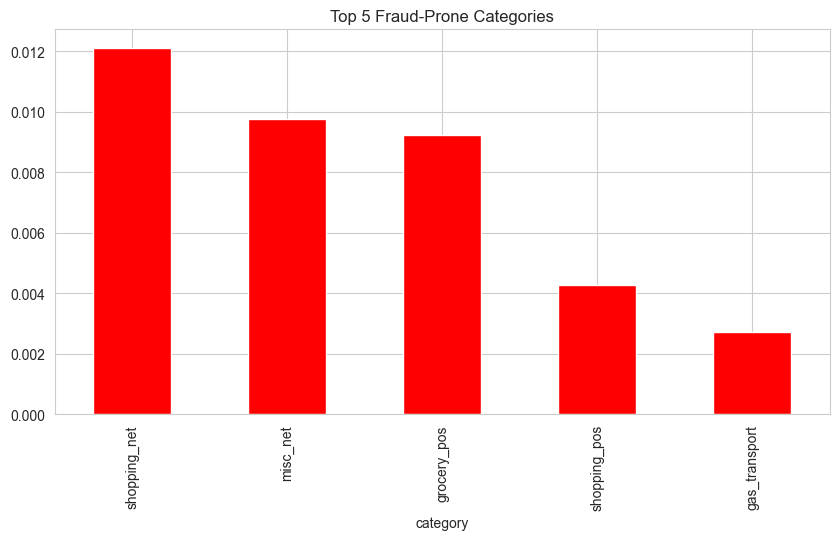

In [22]:
top_fraud = fraud_rate.head(5)

top_fraud.plot(kind="bar", figsize=(10,5), color="red")
plt.title("Top 5 Fraud-Prone Categories")
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\bivariate\Top5_Fraud_category_dist.png", dpi=300, bbox_inches='tight')
plt.show()

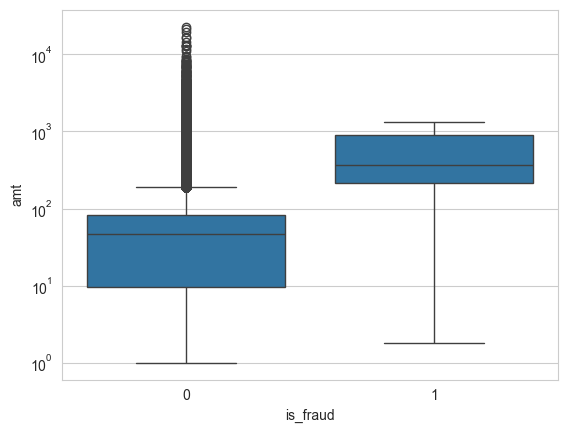

In [23]:
sns.boxplot(data=data, x="is_fraud", y="amt")
plt.yscale("log")
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\bivariate\Fraud_amt_dist.png", dpi=300, bbox_inches='tight')

<Axes: xlabel='amt', ylabel='Density'>

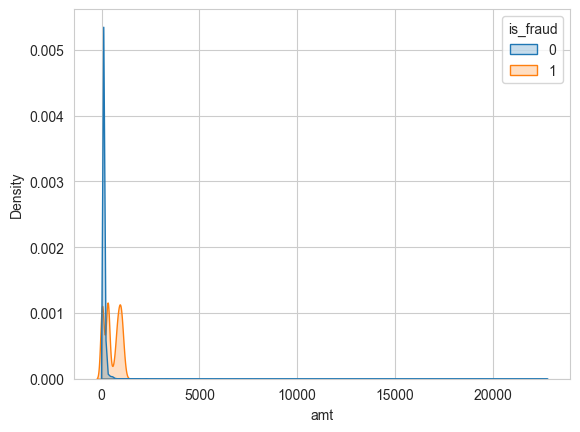

In [24]:
sns.kdeplot(data=data, x="amt", hue="is_fraud", fill=True, common_norm=False)

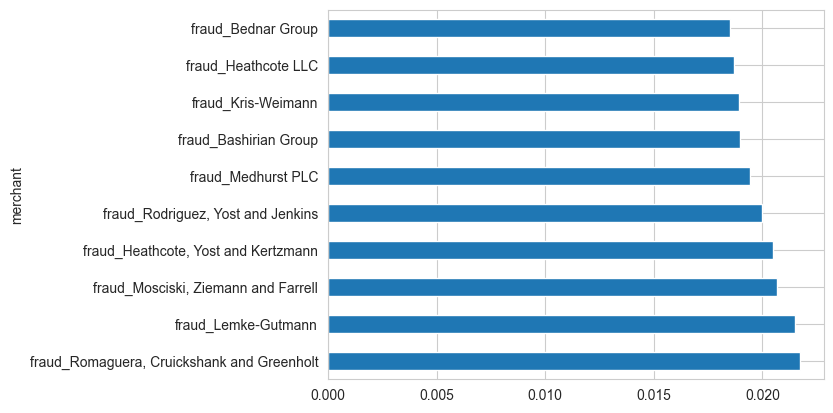

In [25]:
merchant_fraud = data.groupby("merchant")["is_fraud"].mean().sort_values(ascending=False).head(10)

merchant_fraud.plot(kind="barh")
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\bivariate\Fraud_merchant_dist.png", dpi=300, bbox_inches='tight')

## Time Series Plots

In [26]:
file_path =  r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\metadata\Credit_cols_classified.json"
with open(file_path, 'r') as file:
    col_class = json.load(file)
print(col_class)

{'target_col': 'is_fraud', 'uniq_cols': ['cc_num', 'trans_num'], 'num_cols': ['amt', 'city_pop'], 'cat_cols': ['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job'], 'loc_cols': ['long', 'lat', 'merch_lat', 'merch_long', 'zip'], 'time_cols': ['trans_date_trans_time', 'dob', 'unix_time']}


In [27]:
data["trans_date_trans_time"] = pd.to_datetime(data["trans_date_trans_time"])

C:\Users\HP\AppData\Local\Temp\ipykernel_5292\1115927929.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["trans_date_trans_time"] = pd.to_datetime(data["trans_date_trans_time"])


In [28]:
data['trans_date_trans_time'].dt.month.unique()

array([ 6,  7,  8,  9, 10, 11, 12], dtype=int32)

The data stroes is only for months June to December or we can say that there is data only for quarter Q2 and Q3

In [29]:
data['trans_date_trans_time'].dt.year.unique()

array([2020], dtype=int32)

We only have 2020 data. Most likely is a sample size.

In [30]:
data["trans_date_trans_time"].head()

0   2020-06-21 12:14:00
1   2020-06-21 12:14:00
2   2020-06-21 12:14:00
3   2020-06-21 12:15:00
4   2020-06-21 12:15:00
Name: trans_date_trans_time, dtype: datetime64[ns]

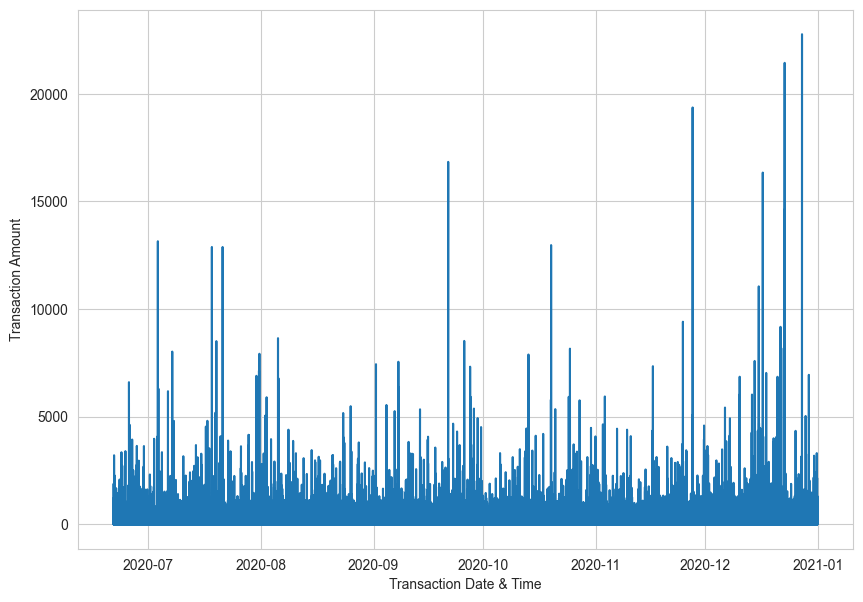

<Figure size 640x480 with 0 Axes>

In [31]:
plt.figure(figsize=(10,7))
plt.plot(data["trans_date_trans_time"],data["amt"])
plt.xlabel("Transaction Date & Time")
plt.ylabel("Transaction Amount")
plt.show()
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\Month_Wise_Transaction_amt.png")

In [32]:
month_fraud_cnt = data.groupby(data["trans_date_trans_time"].dt.month)["is_fraud"].sum()
month_fraud_cnt

trans_date_trans_time
6     133
7     321
8     415
9     340
10    384
11    294
12    258
Name: is_fraud, dtype: int64

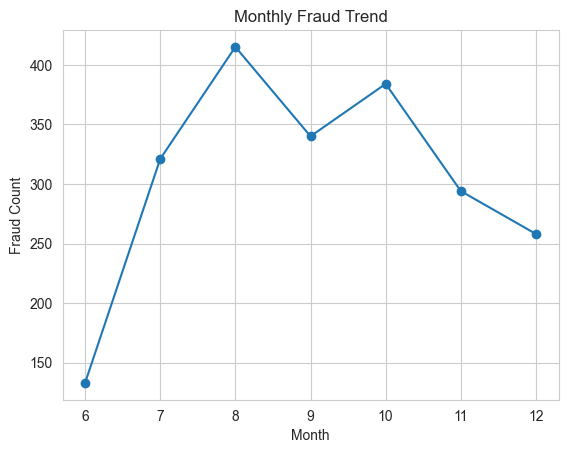

<Figure size 640x480 with 0 Axes>

In [33]:
plt.plot(month_fraud_cnt.index, month_fraud_cnt.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Fraud Count")
plt.title("Monthly Fraud Trend")
plt.show()
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\Monthly_Fraud_Trend.png")

Monthly fraud count is decreasing month by month

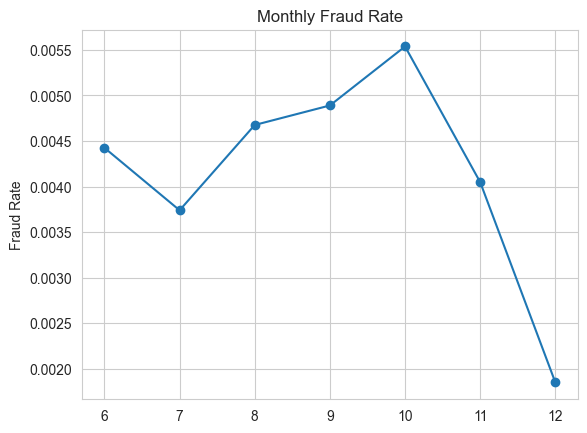

<Figure size 640x480 with 0 Axes>

In [34]:
monthly = data.groupby(data["trans_date_trans_time"].dt.month).agg({
    "is_fraud": ["sum", "count"]})
monthly.columns = ["fraud_count", "total_txn"]
monthly["fraud_rate"] = monthly["fraud_count"] / monthly["total_txn"]
plt.plot(monthly.index, monthly["fraud_rate"], marker='o')
plt.ylabel("Fraud Rate")
plt.title("Monthly Fraud Rate")
plt.show()
plt.savefig(r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\notebooks\Credit_Card_Fraud_Data\plots\Monthly_Fraud_Rate.png")

Monthly Fraud Rate decreased sharply after October.